## Vectorizing Logistic Regression

### Forward Propagation
For $m=1$ (one example),

$$
\mathbf{x} = 
\begin{pmatrix}
x_1 \\
x_2 \\
\dots \\
x_n
\end{pmatrix}
,\qquad
y\in \{0,1\}
$$

Loss function:

$$
\begin{align}
z &= \mathbf{w}^{T}\mathbf{x}+b \\
\hat{y} &= \sigma{(z)} \\
\mathcal{L}(\mathbf{w},b) &= -y\log{\hat{y}}-(1-y)\log{(1-\hat{y})}
\end{align}
$$

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from src.utils.compgraph import CompGraph
os.environ['PATH'] += ':/Library/TeX/texbin'

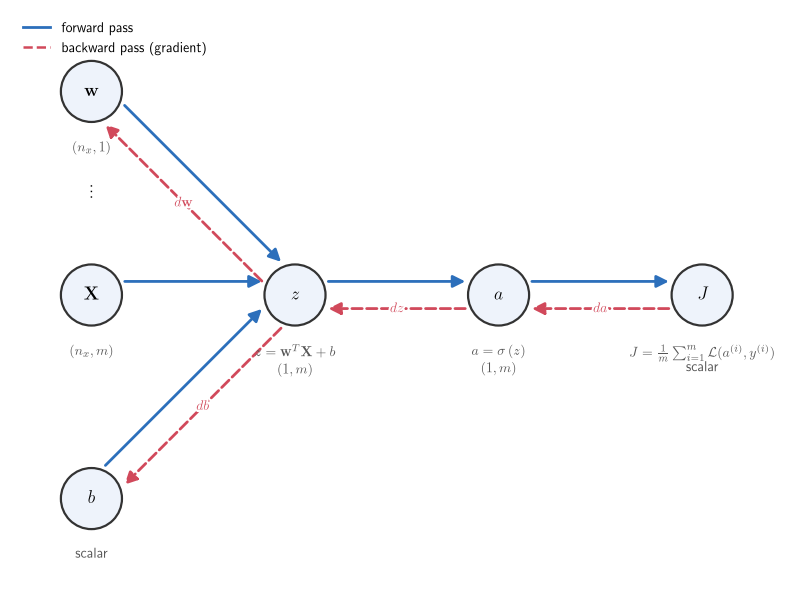

In [14]:
def logistic_regression_example():
    """Builds the classic single-example logistic regression graph:
    z = w*x + b, a = sigmoid(z), L = loss(a, y)
    """
    w = r"\mathbf{{w}}"
    b = "b"
    X = r"\mathbf{{X}}"
    z = "z"
    a = "a"
    L = r"\mathcal{{L}}"
    J = r"J"
    g = CompGraph()
    g.add_node(rf"${X}$", (0, 1.5), op=r"$(n_x,m)$")
    g.add_node(r"$\mathbf{\vdots}$", (0, 3.0), enclose=False)
    g.add_node(rf"${w}$", (0, 4.5), op=r"$(n_x,1)$")
    g.add_node(rf"${b}$", (0, -1.5), op="scalar")
    g.add_node(rf"${z}$", (3, 1.5), op=fr"$\begin{{array}}{{c}} {z} = {w}^T{X} + {b} \\ (1,m) \end{{array}}$")
    g.add_node(rf"${a}$", (6, 1.5), op=fr"$\begin{{array}}{{c}}{a} = \sigma\,({z}) \\ (1,m) \end{{array}}$")
    g.add_node(rf"${J}$", (9, 1.5), op=fr"$J = \frac{{1}}{{m}}\sum_{{i=1}}^{{m}}{{{L}({a}^{{(i)}},y^{{(i)}})}}$" + "\nscalar")

    for src in [rf"${X}$", rf"${w}$", rf"${b}$"]:
        g.add_edge(src, rf"${z}$")
    g.add_edge(rf"${z}$", rf"${a}$")
    g.add_edge(rf"${a}$", rf"${J}$")

    g.add_backward_edge(rf"${J}$", rf"${a}$", label=rf"$d{a}$")
    g.add_backward_edge(rf"${a}$", rf"${z}$", label=rf"$d{z}$")
    g.add_backward_edge(rf"${z}$", rf"${w}$", label=rf"$d{w}$")
    g.add_backward_edge(rf"${z}$", rf"${b}$", label=rf"$d{b}$")

    return g.draw()

plt.rcParams['text.usetex'] = True






fig,ax = logistic_regression_example()
plt.show()

### Forward Pass ($n_x$ features, $m$ training examples)
$$
\begin{align*}
    z &= \mathbf{w}^{T}\mathbf{X} + b\\
    a &= \sigma{(z)}\\
    \mathcal{L} &= -y\log{a}-(1-y)\log{(1-a)}\\
    J &= \frac{1}{m}\sum_{j=1}^{m}\mathcal{L}(a^{(j)},y^{(j)})
\end{align*}
$$

### Backward pass
$$
\begin{align*}
    da &= \frac{1}{m}\sum_{j=1}^{m}\frac{a^{(j)}-y^{(j)}}{a^{(j)}(1-a^{(j)})} = \frac{1}{m}\sum_{j=1}^{m}da^{(j)}\\
    dz &= \frac{1}{m}\sum_{j=1}^{m}a^{(j)}-y^{(j)}=\frac{1}{m}\sum_{j=1}^{m}dz^{(j)} \\
    dw_i &= \frac{1}{m} \sum_{j=1}^{m}{dz^{(j)}x^{(j)}_i} \\
\end{align*}
$$

$$\boxed{\,d\mathbf{w} = \frac{1}{m}\mathbf{X}dz^{T},\quad db = \frac{1}{m}\sum_{j=1}^{m}dz^{(j)}\,}$$